## Import Library

In [1]:
import os
import zipfile
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)

print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"sklearn : {sklearn.__version__}")
print(f"random seed : {SEED}")

python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
matplotlib : 3.10.0
sklearn : 1.6.1
random seed : 42


## Memuat Manifest

In [2]:
MANIFEST_PATH = "/kaggle/input/notebooks/kkndesalalatedzong/notebook00/manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)
valid = manifest[manifest["n_missing_kinds"] == 0].copy()

print(f"Total baris manifest       : {len(manifest)}")
print(f"Dikeluarkan (berkas hilang): {len(manifest) - len(valid)}")
print(f"Eksekusi valid diproses    : {len(valid)}")
print()
print("=== Rincian per grup ===")
print(valid.groupby("group").size().to_string())


Total baris manifest       : 1970
Dikeluarkan (berkas hilang): 1
Eksekusi valid diproses    : 1969

=== Rincian per grup ===
group
extra        360
mix          100
original    1439
variants      70


## Konfigurasi

In [3]:
COLS = ["t_s", "t_ns", "addr", "size", "entropy", "type"]
CSV_KINDS = ["ata_read", "ata_write", "mem_read", "mem_write", "mem_readwrite", "mem_exec"]
RANSOMWARE_CLASSES = {"Conti", "Darkside", "LockBit", "REvil", "Ryuk", "WannaCry"}

CHECKPOINT_GRID = list(range(1, 31))
MAX_T_REL = max(CHECKPOINT_GRID)
CHUNK_SIZE = 100_000

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES


def is_ransomware_label(class_name):
    return any(r in class_name for r in RANSOMWARE_CLASSES)


assert len(STORAGE_FEATURE_NAMES) == 5 and len(MEMORY_FEATURE_NAMES) == 18
print(f"Grid checkpoint final: {CHECKPOINT_GRID} ({len(CHECKPOINT_GRID)} titik)")

for name in ["Conti", "AESCrypt", "Conti_03", "AESCrypt_Conti", "Firefox_Office_REvil", "Idle"]:
    print(f"  is_ransomware_label({name!r}) = {is_ransomware_label(name)}")


Grid checkpoint final: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30] (30 titik)
  is_ransomware_label('Conti') = True
  is_ransomware_label('AESCrypt') = False
  is_ransomware_label('Conti_03') = True
  is_ransomware_label('AESCrypt_Conti') = True
  is_ransomware_label('Firefox_Office_REvil') = True
  is_ransomware_label('Idle') = False


## Fungsi I/O & Fitur

In [4]:
def find_payload(run_dir, kind):
    csv_path = os.path.join(run_dir, f"{kind}.csv")
    zip_path = os.path.join(run_dir, f"{kind}.zip")
    if os.path.exists(csv_path):
        return csv_path, "csv"
    if os.path.exists(zip_path):
        return zip_path, "zip"
    return None, None


def read_until(path, ext, max_t_rel, chunksize=CHUNK_SIZE):
    chunks = []
    state = {"t0": None}

    def consume(reader):
        for chunk in reader:
            if state["t0"] is None:
                state["t0"] = chunk["t_s"].iloc[0] + chunk["t_ns"].iloc[0] / 1e9
            chunk = chunk.assign(t_rel=(chunk["t_s"] + chunk["t_ns"] / 1e9) - state["t0"])
            chunks.append(chunk)
            if chunk["t_rel"].iloc[-1] > max_t_rel:
                break

    if ext == "csv":
        consume(pd.read_csv(path, header=None, names=COLS, chunksize=chunksize))
    else:
        with zipfile.ZipFile(path) as z:
            inner = [n for n in z.namelist() if n.endswith(".csv")][0]
            with z.open(inner) as f:
                consume(pd.read_csv(f, header=None, names=COLS, chunksize=chunksize))

    df = pd.concat(chunks, ignore_index=True)
    return df[df["t_rel"] <= max_t_rel]


def _var_or_zero(series):
    return series.var(ddof=1) if len(series) > 1 else 0.0


def _mean_or_zero(series):
    return series.mean() if len(series) > 0 else 0.0


def storage_features(ata_read_df, ata_write_df, w):
    r = ata_read_df[ata_read_df["t_rel"] < w]
    wr = ata_write_df[ata_write_df["t_rel"] < w]
    return {
        "T_s_r": r["size"].sum() / w,
        "T_s_w": wr["size"].sum() / w,
        "V_s_r": _var_or_zero(r["addr"]),
        "V_s_w": _var_or_zero(wr["addr"]),
        "H_s_w": _mean_or_zero(wr["entropy"]),
    }


def memory_features(mem_read_df, mem_write_df, mem_readwrite_df, mem_exec_df, w):
    r = mem_read_df[mem_read_df["t_rel"] < w]
    wr = mem_write_df[mem_write_df["t_rel"] < w]
    rw = mem_readwrite_df[mem_readwrite_df["t_rel"] < w]
    x = mem_exec_df[mem_exec_df["t_rel"] < w]

    feats = {"H_m_w": _mean_or_zero(wr["entropy"]), "H_m_rw": _mean_or_zero(rw["entropy"])}
    for label, type_val in [("4KB", 1), ("2MB", 2), ("MMIO", 4)]:
        for op_name, d in [("r", r), ("w", wr), ("rw", rw), ("x", x)]:
            feats[f"C_{label}_{op_name}"] = int((d["type"] == type_val).sum())
    for op_name, d in [("r", r), ("w", wr), ("rw", rw), ("x", x)]:
        feats[f"V_m_{op_name}"] = _var_or_zero(d["addr"])
    return feats


## Split Original

In [5]:
original_valid = valid[valid["group"] == "original"].copy()

train_df, temp_df = train_test_split(
    original_valid, test_size=0.30, stratify=original_valid["class"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class"], random_state=SEED
)

split_rows = []
for df_part, label in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    for _, row in df_part.iterrows():
        split_rows.append({"path": row["path"], "group": row["group"], "class": row["class"],
                            "hw": row["hw"], "split": label})

external_df = valid[valid["group"] != "original"]
for _, row in external_df.iterrows():
    split_rows.append({"path": row["path"], "group": row["group"], "class": row["class"],
                        "hw": row["hw"], "split": "external"})

split_assignment = pd.DataFrame(split_rows)
split_assignment.to_csv("/kaggle/working/split_assignment.csv", index=False)

print("Jumlah eksekusi per split")
print(split_assignment["split"].value_counts().to_string())
print()
print("Jumlah eksekusi per (split, class)")
print(split_assignment[split_assignment.split.isin(["train","val","test"])]
      .groupby(["split", "class"]).size().unstack(fill_value=0).to_string())


Jumlah eksekusi per split
split
train       1007
external     530
val          216
test         216

Jumlah eksekusi per (split, class)
class  AESCrypt  Conti  Darkside  Firefox  Idle  LockBit  Office  REvil  Ryuk  SDelete  WannaCry  Zip
split                                                                                                
test         18     18        18       18    18       18      18     18    18       18        18   18
train        84     84        84       84    84       83      84     84    84       84        84   84
val          18     18        18       18    18       18      18     18    18       18        18   18


In [6]:
print("Verifikasi keseimbangan hardware antar split")
hw_balance = (split_assignment[split_assignment.split.isin(["train","val","test"])]
              .groupby(["hw", "split"]).size().unstack(fill_value=0))
hw_balance_pct = (hw_balance.T / hw_balance.sum(axis=1)).T.round(3)
print(hw_balance_pct.to_string())

Verifikasi keseimbangan hardware antar split
split           test  train    val
hw                                
ddr4-1600-16g  0.192  0.608  0.200
ddr4-1600-8g   0.158  0.658  0.183
ddr4-1866-16g  0.125  0.700  0.175
ddr4-1866-8g   0.225  0.633  0.142
ddr4-2133-16g  0.146  0.690  0.163
ddr4-2133-8g   0.121  0.746  0.133
ddr4-2666-16g  0.142  0.742  0.117
ddr4-2666-8g   0.217  0.650  0.133
ddr4-3200-16g  0.117  0.800  0.083
ddr4-3200-8g   0.092  0.733  0.175


## Ekstraksi Fitur

In [7]:
GOLD_FEATURES_PATH = "/kaggle/working/features_gold.csv"

if os.path.exists(GOLD_FEATURES_PATH):
    done_paths = set(pd.read_csv(GOLD_FEATURES_PATH, usecols=["path"])["path"].unique())
    print(f"Melanjutkan proses sebelumnya: {len(done_paths)} eksekusi sudah selesai, dilewati.")
else:
    done_paths = set()

todo = valid[~valid["path"].isin(done_paths)]
print(f"Eksekusi tersisa untuk diproses: {len(todo)} dari {len(valid)}")

first_write = not os.path.exists(GOLD_FEATURES_PATH)
buffer = []
FLUSH_EVERY_N_EXEC = 50
PROGRESS_EVERY = 100

for i, (_, run) in enumerate(todo.iterrows()):
    dfs = {kind: read_until(*find_payload(run["path"], kind), MAX_T_REL) for kind in CSV_KINDS}

    for w in CHECKPOINT_GRID:
        row = {
            "path": run["path"],
            "group": run["group"],
            "class": run["class"],
            "hw": run["hw"],
            "is_ransomware": is_ransomware_label(run["class"]),
            "window_s": w,
        }
        row.update(storage_features(dfs["ata_read"], dfs["ata_write"], w))
        row.update(memory_features(dfs["mem_read"], dfs["mem_write"], dfs["mem_readwrite"], dfs["mem_exec"], w))
        buffer.append(row)

    if (i + 1) % FLUSH_EVERY_N_EXEC == 0:
        pd.DataFrame(buffer).to_csv(GOLD_FEATURES_PATH, mode="a", header=first_write, index=False)
        first_write = False
        buffer = []

    if (i + 1) % PROGRESS_EVERY == 0:
        print(f"  ... {i + 1}/{len(todo)} eksekusi diproses")

if buffer:
    pd.DataFrame(buffer).to_csv(GOLD_FEATURES_PATH, mode="a", header=first_write, index=False)

print(f"\nSelesai. Fitur tersimpan di: {GOLD_FEATURES_PATH}")


Eksekusi tersisa untuk diproses: 1969 dari 1969
  ... 100/1969 eksekusi diproses
  ... 200/1969 eksekusi diproses
  ... 300/1969 eksekusi diproses
  ... 400/1969 eksekusi diproses
  ... 500/1969 eksekusi diproses
  ... 600/1969 eksekusi diproses
  ... 700/1969 eksekusi diproses
  ... 800/1969 eksekusi diproses
  ... 900/1969 eksekusi diproses
  ... 1000/1969 eksekusi diproses
  ... 1100/1969 eksekusi diproses
  ... 1200/1969 eksekusi diproses
  ... 1300/1969 eksekusi diproses
  ... 1400/1969 eksekusi diproses
  ... 1500/1969 eksekusi diproses
  ... 1600/1969 eksekusi diproses
  ... 1700/1969 eksekusi diproses
  ... 1800/1969 eksekusi diproses
  ... 1900/1969 eksekusi diproses

Selesai. Fitur tersimpan di: /kaggle/working/features_gold.csv


In [8]:
features_gold = pd.read_csv(GOLD_FEATURES_PATH)
n_exec_processed = features_gold["path"].nunique()

print(f"Total eksekusi terproses : {n_exec_processed} / {len(valid)}")
print(f"Total baris (eksekusi x checkpoint): {len(features_gold)}")

print("Jumlah baris per grup")
print(features_gold.groupby("group")["path"].nunique().to_string())


Total eksekusi terproses : 1969 / 1969
Total baris (eksekusi x checkpoint): 59070
Jumlah baris per grup
group
extra        360
mix          100
original    1439
variants      70


## T-SNE

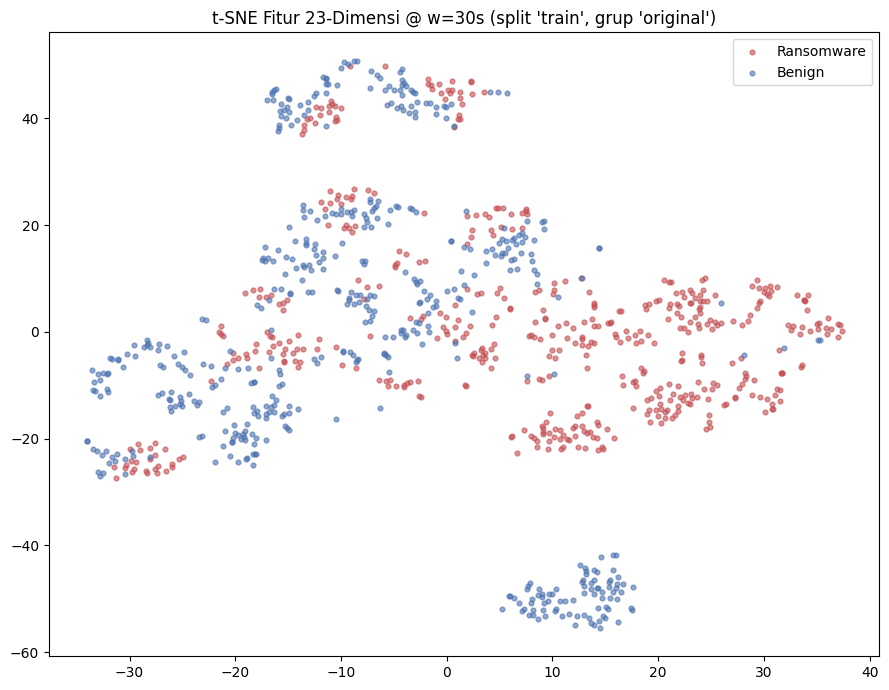

In [9]:
train_paths = set(split_assignment.loc[split_assignment.split == "train", "path"])
viz_data = features_gold[(features_gold.window_s == 30) & (features_gold.path.isin(train_paths))]

X = StandardScaler().fit_transform(viz_data[ALL_FEATURE_NAMES].values)
tsne = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30)
X_2d = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 7))
for is_r, label, color in [(True, "Ransomware", "#C44E52"), (False, "Benign", "#4C72B0")]:
    mask = viz_data["is_ransomware"].values == is_r
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=12, alpha=0.6, label=label, color=color)
ax.set_title("t-SNE Fitur 23-Dimensi @ w=30s (split 'train', grup 'original')")
ax.legend()
plt.tight_layout()
plt.show()
